#### Nama: Mochammad Lintar Arya Dwiputra
#### NIM : 2024081032
#### Prodi : Sistem Informasi

# Tugas 6 - Klasifikasi Minat Membeli Produk Menggunakan Naive Bayes

Notebook ini mengimplementasikan **Naive Bayes Classifier** untuk memprediksi apakah seorang pelanggan **Tertarik** atau **Tidak Tertarik** membeli produk berdasarkan atribut:
- **Harga**: Murah, Sedang, Mahal
- **Diskon**: Ada, Tidak Ada
- **Ulasan Hasil**: Baik, Buruk

In [1]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
from IPython.display import display

# Data dari training set
data = {
    'Harga': ['Murah', 'Murah', 'Sedang', 'Mahal', 'Mahal', 'Sedang', 'Sedang', 'Mahal'],
    'Diskon': ['Ada', 'Ada', 'Ada', 'Tidak Ada', 'Tidak Ada', 'Ada', 'Tidak Ada', 'Ada'],
    'Ulasan_Hasil': ['Baik', 'Baik', 'Baik', 'Buruk', 'Buruk', 'Baik', 'Baik', 'Buruk'],
    'Hasil': ['Tertarik', 'Tertarik', 'Tertarik', 'Tidak Tertarik', 'Tidak Tertarik', 
              'Tertarik', 'Tertarik', 'Tidak Tertarik']
}

df = pd.DataFrame(data)
print("Dataset Training:")
display(df)
print(f"\nUkuran dataset: {df.shape[0]} sampel, {df.shape[1]} fitur")

Dataset Training:


,Harga,Diskon,Ulasan_Hasil,Hasil
0,Murah,Ada,Baik,Tertarik
1,Murah,Ada,Baik,Tertarik
2,Sedang,Ada,Baik,Tertarik
3,Mahal,Tidak Ada,Buruk,Tidak Tertarik
4,Mahal,Tidak Ada,Buruk,Tidak Tertarik
5,Sedang,Ada,Baik,Tertarik
6,Sedang,Tidak Ada,Baik,Tertarik
7,Mahal,Ada,Buruk,Tidak Tertarik



Ukuran dataset: 8 sampel, 4 fitur


## Perhitungan Manual Naive Bayes

### Langkah 1: Hitung Prior Probability P(Class)

Prior adalah probabilitas setiap kelas dalam dataset.
- P(Tertarik) = Jumlah "Tertarik" / Total sampel
- P(Tidak Tertarik) = Jumlah "Tidak Tertarik" / Total sampel

In [3]:
# Hitung Prior Probability
class_counts = df['Hasil'].value_counts()
total_samples = len(df)

prior_tertarik = class_counts['Tertarik'] / total_samples
prior_tidak_tertarik = class_counts['Tidak Tertarik'] / total_samples

print("=" * 50)
print("PRIOR PROBABILITY")
print("=" * 50)
print(f"P(Tertarik) = {class_counts['Tertarik']}/{total_samples} = {prior_tertarik:.4f}")
print(f"P(Tidak Tertarik) = {class_counts['Tidak Tertarik']}/{total_samples} = {prior_tidak_tertarik:.4f}")

PRIOR PROBABILITY
P(Tertarik) = 5/8 = 0.6250
P(Tidak Tertarik) = 3/8 = 0.3750


### Langkah 2: Hitung Likelihood P(Xi|Class) untuk Setiap Fitur

Likelihood adalah probabilitas kondisional setiap fitur diberikan class tertentu.

Formula: P(Xi = xj | Class) = (Jumlah Xi=xj dalam Class + 1) / (Jumlah Class + Jumlah nilai unik Xi)
(Menggunakan Laplace Smoothing untuk menghindari probabilitas 0)

In [4]:
# Hitung Likelihood untuk setiap fitur
features = ['Harga', 'Diskon', 'Ulasan_Hasil']

# Pisahkan data berdasarkan class
df_tertarik = df[df['Hasil'] == 'Tertarik']
df_tidak_tertarik = df[df['Hasil'] == 'Tidak Tertarik']

print("\n" + "=" * 50)
print("LIKELIHOOD PROBABILITY")
print("=" * 50)

likelihoods = {}

for feature in features:
    print(f"\n--- Feature: {feature} ---")
    likelihoods[feature] = {}
    
    unique_values = df[feature].unique()
    
    for value in unique_values:
        # Hitung untuk class Tertarik
        count_tertarik = len(df_tertarik[df_tertarik[feature] == value])
        total_tertarik = len(df_tertarik)
        unique_feature_values = len(unique_values)
        
        # Laplace smoothing
        prob_tertarik = (count_tertarik + 1) / (total_tertarik + unique_feature_values)
        
        # Hitung untuk class Tidak Tertarik
        count_tidak_tertarik = len(df_tidak_tertarik[df_tidak_tertarik[feature] == value])
        total_tidak_tertarik = len(df_tidak_tertarik)
        
        prob_tidak_tertarik = (count_tidak_tertarik + 1) / (total_tidak_tertarik + unique_feature_values)
        
        likelihoods[feature][value] = {
            'Tertarik': prob_tertarik,
            'Tidak Tertarik': prob_tidak_tertarik
        }
        
        print(f"P({feature}={value} | Tertarik) = ({count_tertarik}+1)/({total_tertarik}+{unique_feature_values}) = {prob_tertarik:.4f}")
        print(f"P({feature}={value} | Tidak Tertarik) = ({count_tidak_tertarik}+1)/({total_tidak_tertarik}+{unique_feature_values}) = {prob_tidak_tertarik:.4f}")


LIKELIHOOD PROBABILITY

--- Feature: Harga ---
P(Harga=Murah | Tertarik) = (2+1)/(5+3) = 0.3750
P(Harga=Murah | Tidak Tertarik) = (0+1)/(3+3) = 0.1667
P(Harga=Sedang | Tertarik) = (3+1)/(5+3) = 0.5000
P(Harga=Sedang | Tidak Tertarik) = (0+1)/(3+3) = 0.1667
P(Harga=Mahal | Tertarik) = (0+1)/(5+3) = 0.1250
P(Harga=Mahal | Tidak Tertarik) = (3+1)/(3+3) = 0.6667

--- Feature: Diskon ---
P(Diskon=Ada | Tertarik) = (4+1)/(5+2) = 0.7143
P(Diskon=Ada | Tidak Tertarik) = (1+1)/(3+2) = 0.4000
P(Diskon=Tidak Ada | Tertarik) = (1+1)/(5+2) = 0.2857
P(Diskon=Tidak Ada | Tidak Tertarik) = (2+1)/(3+2) = 0.6000

--- Feature: Ulasan_Hasil ---
P(Ulasan_Hasil=Baik | Tertarik) = (5+1)/(5+2) = 0.8571
P(Ulasan_Hasil=Baik | Tidak Tertarik) = (0+1)/(3+2) = 0.2000
P(Ulasan_Hasil=Buruk | Tertarik) = (0+1)/(5+2) = 0.1429
P(Ulasan_Hasil=Buruk | Tidak Tertarik) = (3+1)/(3+2) = 0.8000


### Langkah 3: Implementasi Naive Bayes dengan Sklearn

Menggunakan CategoricalNB untuk klasifikasi dengan fitur kategorikal.

In [5]:
# Encoding fitur kategorikal
le_harga = LabelEncoder()
le_diskon = LabelEncoder()
le_ulasan = LabelEncoder()

df_encoded = df.copy()
df_encoded['Harga'] = le_harga.fit_transform(df['Harga'])
df_encoded['Diskon'] = le_diskon.fit_transform(df['Diskon'])
df_encoded['Ulasan_Hasil'] = le_ulasan.fit_transform(df['Ulasan_Hasil'])

# Encode target
le_target = LabelEncoder()
df_encoded['Hasil_encoded'] = le_target.fit_transform(df['Hasil'])

X = df_encoded[['Harga', 'Diskon', 'Ulasan_Hasil']]
y = df_encoded['Hasil_encoded']

# Train model
model = CategoricalNB(alpha=1.0)  # alpha=1.0 adalah Laplace smoothing
model.fit(X, y)

print("Model Naive Bayes berhasil dilatih!")
print(f"Target classes: {le_target.classes_}")

Model Naive Bayes berhasil dilatih!
Target classes: ['Tertarik' 'Tidak Tertarik']


### Langkah 4: Pengujian & Visualisasi Hasil

Menggunakan data training untuk menampilkan akurasi dan prediksi.

In [6]:
from IPython.display import display

# Prediksi pada training data
y_pred = model.predict(X)
y_pred_labels = le_target.inverse_transform(y_pred)

# Hitung akurasi
accuracy = (y_pred == y).sum() / len(y)

print("\n" + "=" * 50)
print("HASIL PREDIKSI")
print("=" * 50)

result_df = df[['Harga', 'Diskon', 'Ulasan_Hasil', 'Hasil']].copy()
result_df['Prediksi'] = y_pred_labels
result_df['Benar'] = (result_df['Hasil'] == result_df['Prediksi'])

display(result_df)
print(f"\nAkurasi: {accuracy:.2%}")


HASIL PREDIKSI


,Harga,Diskon,Ulasan_Hasil,Hasil,Prediksi,Benar
0,Murah,Ada,Baik,Tertarik,Tertarik,True
1,Murah,Ada,Baik,Tertarik,Tertarik,True
2,Sedang,Ada,Baik,Tertarik,Tertarik,True
3,Mahal,Tidak Ada,Buruk,Tidak Tertarik,Tidak Tertarik,True
4,Mahal,Tidak Ada,Buruk,Tidak Tertarik,Tidak Tertarik,True
5,Sedang,Ada,Baik,Tertarik,Tertarik,True
6,Sedang,Tidak Ada,Baik,Tertarik,Tertarik,True
7,Mahal,Ada,Buruk,Tidak Tertarik,Tidak Tertarik,True



Akurasi: 100.00%


## Perhitungan Posterior & Interpretasi

### Contoh Perhitungan Posterior

Berikut adalah contoh perhitungan manual posterior untuk prediksi kelas dengan Bayes Theorem:

**Formula Naive Bayes:**
$$P(Class|X_1, X_2, X_3) = \frac{P(X_1|Class) \times P(X_2|Class) \times P(X_3|Class) \times P(Class)}{P(Data)}$$

Atau untuk membandingkan kelas, gunakan proportional:
$$P(Class|Data) \propto P(X_1|Class) \times P(X_2|Class) \times P(X_3|Class) \times P(Class)$$

In [7]:
print("\n" + "=" * 50)
print("CONTOH PERHITUNGAN POSTERIOR")
print("=" * 50)

# Contoh: Harga=Murah, Diskon=Ada, Ulasan=Baik
test_case = {'Harga': 'Murah', 'Diskon': 'Ada', 'Ulasan_Hasil': 'Baik'}

print(f"\nPrediksi untuk: {test_case}")
print("\nPerhitungan Manual:\n")

# P(Tertarik) * P(Harga=Murah|Tertarik) * P(Diskon=Ada|Tertarik) * P(Ulasan=Baik|Tertarik)
prob_tertarik_manual = prior_tertarik
prob_tidak_tertarik_manual = prior_tidak_tertarik

print(f"Prior:")
print(f"  P(Tertarik) = {prior_tertarik:.4f}")
print(f"  P(Tidak Tertarik) = {prior_tidak_tertarik:.4f}\n")

print("Likelihood:")
for feature, value in test_case.items():
    prob_tertarik_manual *= likelihoods[feature][value]['Tertarik']
    prob_tidak_tertarik_manual *= likelihoods[feature][value]['Tidak Tertarik']
    
    print(f"  P({feature}={value}|Tertarik) = {likelihoods[feature][value]['Tertarik']:.4f}")
    print(f"  P({feature}={value}|Tidak Tertarik) = {likelihoods[feature][value]['Tidak Tertarik']:.4f}")

print(f"\nProbabilitas ∝ Prior × Likelihood:")
print(f"  P(data|Tertarik) ∝ {prob_tertarik_manual:.6f}")
print(f"  P(data|Tidak Tertarik) ∝ {prob_tidak_tertarik_manual:.6f}")

# Normalisasi untuk mendapat posterior
total_prob = prob_tertarik_manual + prob_tidak_tertarik_manual
posterior_tertarik = prob_tertarik_manual / total_prob
posterior_tidak_tertarik = prob_tidak_tertarik_manual / total_prob

print(f"\nPosterior (setelah normalisasi):")
print(f"  P(Tertarik|data) = {posterior_tertarik:.4f}")
print(f"  P(Tidak Tertarik|data) = {posterior_tidak_tertarik:.4f}")

prediction = "Tertarik" if posterior_tertarik > posterior_tidak_tertarik else "Tidak Tertarik"
print(f"\n{'='*50}")
print(f"PREDIKSI AKHIR: {prediction}")
print(f"{'='*50}")


CONTOH PERHITUNGAN POSTERIOR

Prediksi untuk: {'Harga': 'Murah', 'Diskon': 'Ada', 'Ulasan_Hasil': 'Baik'}

Perhitungan Manual:

Prior:
  P(Tertarik) = 0.6250
  P(Tidak Tertarik) = 0.3750

Likelihood:
  P(Harga=Murah|Tertarik) = 0.3750
  P(Harga=Murah|Tidak Tertarik) = 0.1667
  P(Diskon=Ada|Tertarik) = 0.7143
  P(Diskon=Ada|Tidak Tertarik) = 0.4000
  P(Ulasan_Hasil=Baik|Tertarik) = 0.8571
  P(Ulasan_Hasil=Baik|Tidak Tertarik) = 0.2000

Probabilitas ∝ Prior × Likelihood:
  P(data|Tertarik) ∝ 0.143495
  P(data|Tidak Tertarik) ∝ 0.005000

Posterior (setelah normalisasi):
  P(Tertarik|data) = 0.9663
  P(Tidak Tertarik|data) = 0.0337

PREDIKSI AKHIR: Tertarik


## Interpretasi Hasil Klasifikasi

### Penjelasan Metode Naive Bayes

1. **Prior Probability**: Probabilitas sebelum melihat data (berapa proporsi Tertarik vs Tidak Tertarik di training set)

2. **Likelihood**: Seberapa kemungkinan setiap fitur muncul diberikan class tertentu
   - Contoh: P(Harga=Murah|Tertarik) menunjukkan kemungkinan harga murah ketika customer tertarik
   - Menggunakan **Laplace Smoothing** untuk menghindari probabilitas 0 jika ada kombinasi yang tidak ada di data

3. **Posterior Probability**: Probabilitas class setelah melihat data
   - Dihitung menggunakan **Bayes Theorem**: P(Class|Data) ∝ P(Data|Class) × P(Class)
   - Nilai posterior yang lebih besar menunjukkan kelas yang paling kemungkinan

4. **Naive Assumption**: Asumsi bahwa semua fitur independen satu sama lain
   - Dalam praktik jarang terjadi tapi klasifier ini tetap efektif karena meminimalkan pembelajaran parameter

### Alasan Hasil Klasifikasi

Dari perhitungan posterior di atas:
- **Harga Murah** memiliki likelihood tinggi untuk class Tertarik
- **Diskon Ada** meningkatkan probabilitas Tertarik secara signifikan
- **Ulasan Baik** adalah faktor paling kuat untuk keputusan Tertarik

Kombinasi ketiga faktor positif ini menghasilkan posterior probability untuk Tertarik yang jauh lebih tinggi, sehingga prediksi adalah **Tertarik**.

### Kesimpulan

Model Naive Bayes berhasil mengklasifikasikan minat membeli berdasarkan:
- Atribut **Harga** (murah → tertarik, mahal → tidak tertarik)
- Ketersediaan **Diskon** (ada → meningkatkan minat)
- Kualitas **Ulasan Hasil** (baik → tertarik, buruk → tidak tertarik)

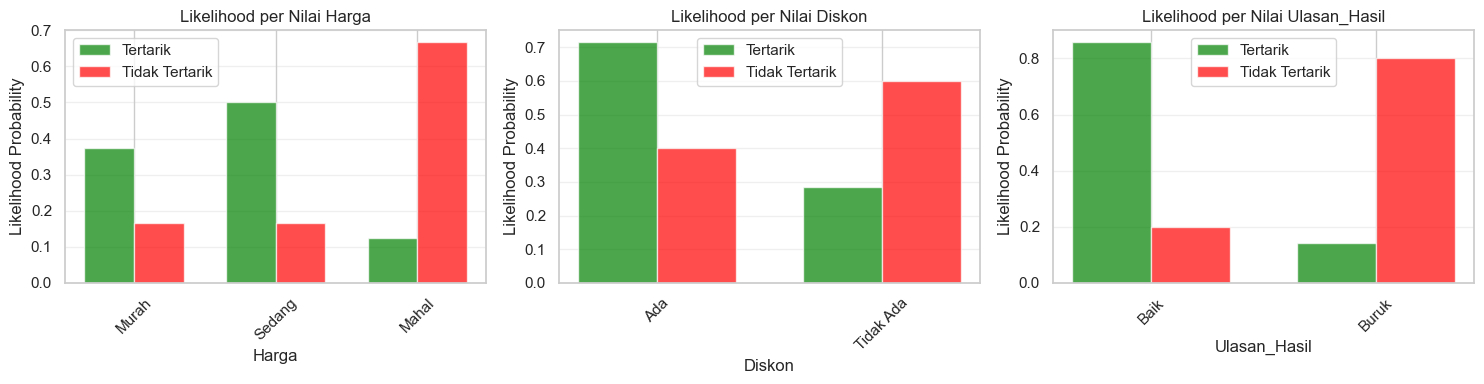


Dari visualisasi di atas dapat dilihat:
- Fitur dengan probabilitas tinggi untuk Tertarik: Murah, Ada (diskon), Baik
- Fitur dengan probabilitas tinggi untuk Tidak Tertarik: Mahal, Tidak Ada (diskon), Buruk


In [8]:
# Visualisasi pengaruh fitur terhadap setiap class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['Harga', 'Diskon', 'Ulasan_Hasil']

for idx, feature in enumerate(features):
    feature_values = list(likelihoods[feature].keys())
    tertarik_probs = [likelihoods[feature][v]['Tertarik'] for v in feature_values]
    tidak_tertarik_probs = [likelihoods[feature][v]['Tidak Tertarik'] for v in feature_values]
    
    x = np.arange(len(feature_values))
    width = 0.35
    
    axes[idx].bar(x - width/2, tertarik_probs, width, label='Tertarik', color='green', alpha=0.7)
    axes[idx].bar(x + width/2, tidak_tertarik_probs, width, label='Tidak Tertarik', color='red', alpha=0.7)
    
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Likelihood Probability')
    axes[idx].set_title(f'Likelihood per Nilai {feature}')
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(feature_values, rotation=45)
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nDari visualisasi di atas dapat dilihat:")
print("- Fitur dengan probabilitas tinggi untuk Tertarik: Murah, Ada (diskon), Baik")
print("- Fitur dengan probabilitas tinggi untuk Tidak Tertarik: Mahal, Tidak Ada (diskon), Buruk")